Read Left & Right image -> Rectify -> Depth Map -> Point Cloud -> BEV

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PyStereo.StereoLib import *
from PyStereo.StereoMatchers import *
from PyStereo.DetectorLib import *
import shutil
import time
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

MAX_RANGE_CM = 100

In [31]:
stereo_rectify_params = load_stereo_camera_params()

In [32]:
left_img  = cv2.imread("input/DemoTest/left_002.png")
right_img = cv2.imread("input/DemoTest/right_002.png")

left_img , right_img  = rectify_stereo_images(left_img,right_img,rectify_params=stereo_rectify_params,show=False ) 


In [ ]:

def use_FS(): # -> Return Matching Function, Model Name
    fs_stereo = FoundationStereoV1(device='cuda')
    return fs_stereo.stereo_matching, "FoundationStereoV1" 

model_func , model_name = use_FS()
disp   = model_func(left_img, right_img)
 
 

Using cache found in E:\Cache\torch\hub\facebookresearch_dinov2_main
using MLP layer as FFN


Missing keys: 0 | Unexpected: 0
FoundationStereo loaded from E:\Pratical_Project\Semester\寒假\PyDepthSystem4\PyStereo\FoundationStereo\checkpoints\Vit-small.pth on cuda


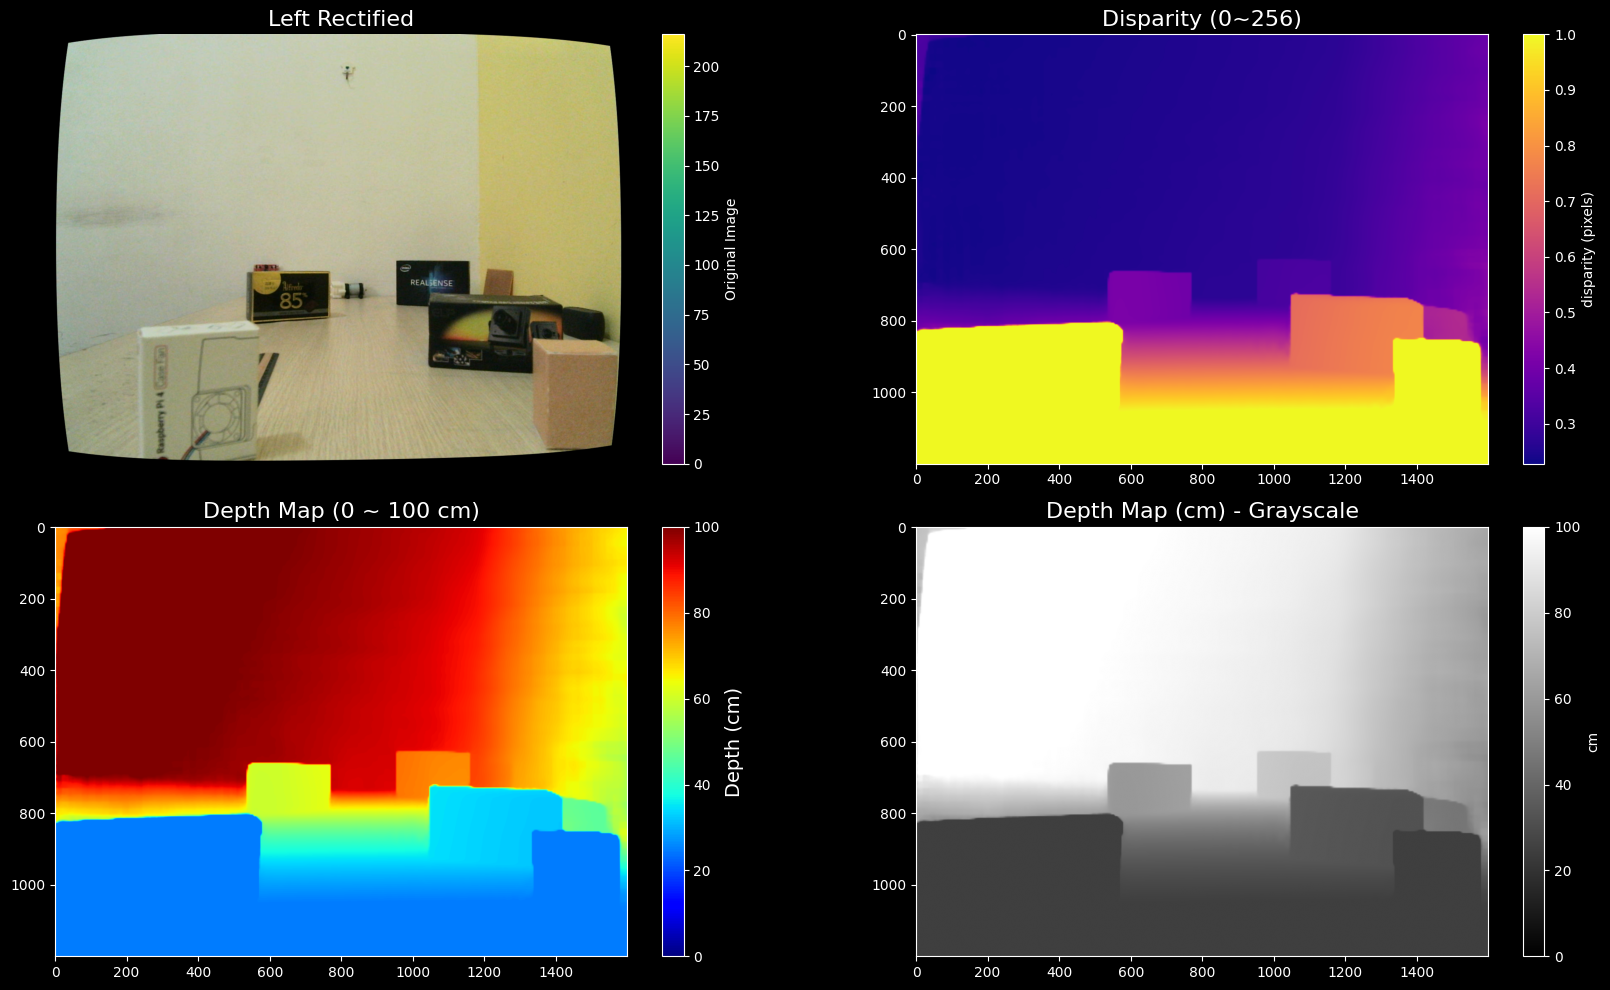

In [34]:
visualize_depth_map(
    left_img,
    disp,
    FoundationStereoV1.max_disp,
    stereo_rectify_params,
    model_name=model_name,
    file_serial_number="002",
    show=False,
    max_range_cm=MAX_RANGE_CM,
    output_dir="TestDemoResult"
)


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from scipy import ndimage  # For morphological noise reduction

def fit_plane_ransac(
    pts, 
    thresh=25.0,          
    min_height=80.0,      # Lowered to better detect boxes (80 mm ~8 cm)
    max_iter=2000,
    min_inliers=3000,     
    sample_ratio=0.2      
):
    N = pts.shape[0]
    if N < 1000:
        return None, None, None, None

    if sample_ratio < 1.0 and N > 50000:
        sample_size = max(30000, int(N * sample_ratio))
        idx = np.random.choice(N, sample_size, replace=False)
        pts_sample = pts[idx]
    else:
        pts_sample = pts

    N_sample = pts_sample.shape[0]
    best_inliers = 0
    best_normal = None
    best_d = None
    best_inlier_mask = None

    for _ in range(max_iter):
        idx3 = np.random.choice(N_sample, 3, replace=False)
        p1, p2, p3 = pts_sample[idx3]
        v1 = p2 - p1
        v2 = p3 - p1
        normal = np.cross(v1, v2)
        norm_len = np.linalg.norm(normal)
        if norm_len < 1e-6:
            continue
        normal /= norm_len
        d = -np.dot(normal, p1)

        dist = np.abs(np.dot(pts, normal) + d)
        inlier_mask = dist < thresh
        num_inliers = np.sum(inlier_mask)

        if num_inliers > best_inliers:
            best_inliers = num_inliers
            best_normal = normal
            best_d = d
            best_inlier_mask = inlier_mask.copy()

    if best_inliers < min_inliers or best_normal is None:
        return None, None, None, None

    if abs(best_normal[2]) < 0.99:
        print("Plane too tilted, discarding...")
        return None, None, None, None

    if best_normal[2] < 0:
        best_normal = -best_normal
        best_d = -best_d

    signed_dist = np.dot(pts, best_normal) + best_d

    ground_mask   = np.abs(signed_dist) < thresh
    obstacle_mask = signed_dist > min_height

    print(f"Found plane with {best_inliers:,} inliers / {N:,} points ({best_inliers/N*100:.1f}%)")
    print("Ground plane stats: mean signed dist:", signed_dist[ground_mask].mean(), "std:", signed_dist[ground_mask].std(), "normal:", best_normal, "d:", best_d)

    return best_normal, best_d, ground_mask, obstacle_mask

def generate_bev_from_depth(disp, rectify_params, max_range_cm=110, model_name="", show=False, output_dir="output", 
                            cell_size_mm=50, min_height_mm=20, yolo_labels=None, class_names=None , serial_number=""):  # Lowered min_height
    points3d = cv2.reprojectImageTo3D(disp, rectify_params["Q"])
    original_x = points3d[:,:,0]
    original_y = points3d[:,:,1]
    original_z = points3d[:,:,2]
    x = original_x
    y = original_z
    z = -original_y

    max_range_mm = max_range_cm * 10
    min_depth_mm = 250  # Ignore points closer than 25cm for plane fitting and obstacle detection
    mask = (disp > 0) & (original_z > min_depth_mm) & (original_z < max_range_mm) & \
           (z > -200) & (z < 200)
    pts = np.c_[x[mask], y[mask], z[mask]]

    if pts.shape[0] < 1000:
        print("Not enough points.")
        return

    normal, d, ground_mask, obstacle_mask = fit_plane_ransac(pts, thresh=25, min_height=min_height_mm)

    if normal is None:
        print("Failed to fit ground plane.")
        return

    ground_pts = pts[ground_mask]
    ground_x, ground_y = ground_pts[:,0], ground_pts[:,1]

    obs_pts = pts[obstacle_mask]
    obs_x, obs_y = obs_pts[:,0], obs_pts[:,1]

    # Shorten X axis: use actual min/max from points + small padding
 
    min_x = -400
    max_x = 400


    min_y = 0
    max_y = max_range_mm

    num_bins_x = math.ceil((max_x - min_x) / cell_size_mm)
    num_bins_y = math.ceil((max_y - min_y) / cell_size_mm)

    bins_x = np.linspace(min_x, min_x + num_bins_x * cell_size_mm, num_bins_x + 1)
    bins_y = np.linspace(min_y, min_y + num_bins_y * cell_size_mm, num_bins_y + 1)

    hist_ground, _, _ = np.histogram2d(ground_y, ground_x, bins=(bins_y, bins_x))
    hist_obs, _, _ = np.histogram2d(obs_y, obs_x, bins=(bins_y, bins_x))

    H, W = hist_ground.shape
    bev = np.zeros((H, W, 3), dtype=np.uint8)   

    walkable_mask = (hist_ground > 0) & (hist_obs == 0)

    # Walkable 
    bev[walkable_mask] = [128, 128, 128]



    # Reduce near noise: erode small black
    structure = ndimage.generate_binary_structure(2, 1)

    bev_black = np.all(bev == [0, 0, 0], axis=2)   # (H,W)

    bev_black_eroded = ndimage.binary_erosion(
        bev_black,
        structure=structure,
        iterations=2
    )


    small_black = bev_black & ~bev_black_eroded
    bev[small_black] = [128, 128, 128]
 

    near_dist_mm = 250
    num_near_bins = math.ceil(near_dist_mm / cell_size_mm)

    # 近距離強制 walkable
    bev[:num_near_bins, :] = 128

 
 
    # Visualization
    fig, ax = plt.subplots(figsize=(8, 8))  
    fig.set_size_inches(8, 8, forward=True)
 
    ax.imshow(
        bev,
        extent=[min_x, max_x, min_y, max_y],
        origin='lower',
        interpolation='nearest'
    )
    ax.set_title(f"BEV Map ({model_name}) - Max Range: {max_range_cm} cm", fontsize=16)

    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (Depth, mm)")


    ax.set_aspect('equal')

    class_colors = {}
    if yolo_labels and class_names:
        np.random.seed(42)  
        num_classes = len(class_names)
        colors = np.random.randint(0, 255, size=(num_classes, 3)) / 255.0  
        
        depth_map_mm = original_z  
        H, W = depth_map_mm.shape   

        for label in yolo_labels:   
            class_id, cx, cy, bw, bh = label  
            class_name = class_names[int(class_id)]
            color = colors[int(class_id)]   

            px = int(cx * W) 
            py = int(cy * H)
            depth = depth_map_mm[py, px] 
            if depth <= 0 or depth >= max_range_mm:  
                continue

            point3d = points3d[py, px]  
            bev_x = point3d[0]  
            bev_y = point3d[2]

            obj_size_mm = 100   
            rect = patches.Rectangle(
                (bev_x - obj_size_mm/2, bev_y - obj_size_mm/2),  
                obj_size_mm, obj_size_mm,  
                linewidth=2, edgecolor=color, facecolor=color  
            )
            ax.add_patch(rect)  

            class_colors[class_name] = color   
  

    # Legend 
    items = [
        ('Black: Obstacle', 'black'),
        ('Gray: Walkable', 'gray')
    ] + [(class_name, color) for class_name, color in class_colors.items()]

    if items:

        item_height = 35
        padding_top = 20
        padding_bottom = 20

        rows = len(items)
        legend_height_total = rows * item_height + padding_top + padding_bottom
        legend_y = -legend_height_total

        ax.set_ylim(legend_y, max_y)

        bg_rect = patches.Rectangle(
            (min_x, legend_y),
            max_x - min_x,
            legend_height_total,
            facecolor='white',
            edgecolor='none',
            zorder=1
        )
        ax.add_patch(bg_rect)

        x_start = min_x + 30
        y_top = legend_y + legend_height_total - padding_top

        for i, (label, col) in enumerate(items):

            y_pos = y_top - i * item_height

            ax.add_patch(
                patches.Rectangle(
                    (x_start, y_pos - 20),
                    25, 25,
                    color=col,
                    zorder=2
                )
            )

            ax.text(
                x_start + 40,
                y_pos - 8,
                label,
                va='center',
                fontsize=11,
                color='black',
                zorder=2
            )


 

    x_range = max_x - min_x
    y_range = max_y - legend_y

    max_range_plot = max(x_range, y_range)

    x_center = (max_x + min_x) / 2
    y_center = (max_y + legend_y) / 2

    ax.set_xlim(
        x_center - max_range_plot / 2,
        x_center + max_range_plot / 2
    )

    ax.set_ylim(
        y_center - max_range_plot / 2,
        y_center + max_range_plot / 2
    )

 

    plt.tight_layout() 
    save_path = f"{output_dir}/bev_{model_name}_{serial_number}.png"
 
    plt.savefig(save_path, dpi=200, bbox_inches='tight', pad_inches=0)
    if show:
        ax.imshow(
            bev,
            extent=[min_x, max_x, min_y, max_y],
            origin='lower',
            interpolation='nearest'
        )
    else:
        plt.close()  
    

    
    

Found plane with 338,432 inliers / 789,053 points (42.9%)
Ground plane stats: mean signed dist: -3.4471304 std: 11.801475 normal: [-0.05313657 -0.05590253  0.9970213 ] d: 124.32655


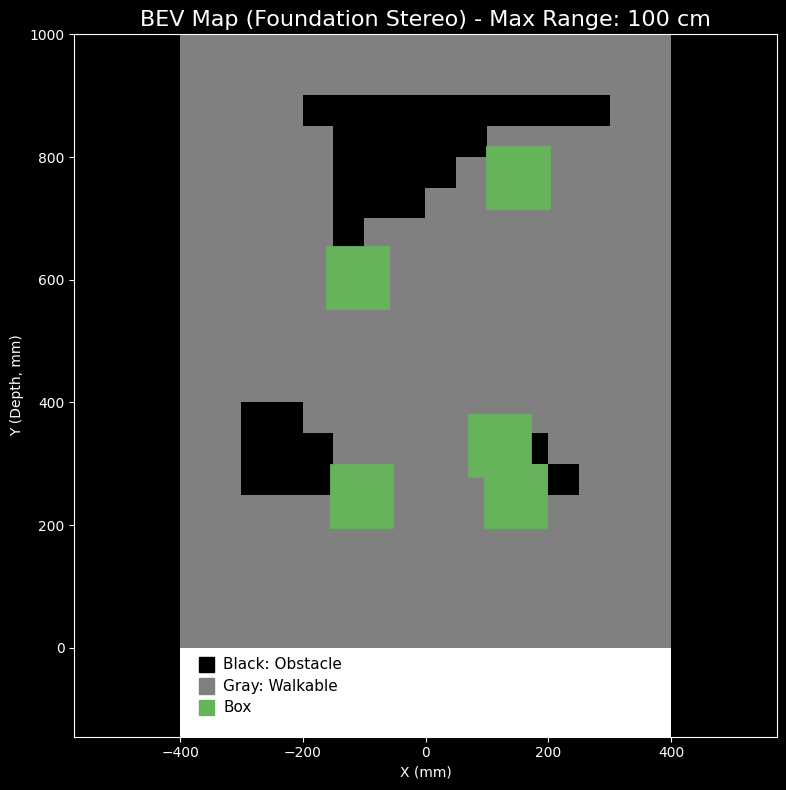

In [70]:
YOLO_form_Labels = load_yolo_labels("input/DemoTest/left_002.txt")


CLASSES = [
    "Box",
 
]

generate_bev_from_depth(disp, stereo_rectify_params, yolo_labels=YOLO_form_Labels ,class_names=CLASSES , max_range_cm=MAX_RANGE_CM, model_name="Foundation Stereo", show=True ,serial_number ="002")